# Deliverable 3 — Community Detection & Genre Alignment

Self-contained notebook. Rebuilds the co-watch network, runs Louvain community
detection on the GCC, measures genre alignment (NMI, purity), builds the genre
co-occurrence network, and identifies bridge anime.

In [1]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# python-louvain exports community.best_partition; a different 'community' pkg may be installed
try:
    import community as _c
    _ = _c.best_partition   # raises AttributeError if wrong package
except (ImportError, AttributeError):
    print('Installing python-louvain...')
    pip_install('python-louvain')

try:
    import powerlaw
except ImportError:
    print('Installing powerlaw...')
    pip_install('powerlaw')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

print('All packages ready.')

Installing python-louvain...
Installing powerlaw...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 5.2 MB/s eta 0:00:00
All packages ready.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from scipy import sparse, stats
from scipy.sparse import csr_matrix
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations

try:
    import community as community_louvain
    _ = community_louvain.best_partition  # verify it's python-louvain
    HAVE_LOUVAIN = True
except (ImportError, AttributeError):
    HAVE_LOUVAIN = False
    print('python-louvain unavailable — will use NetworkX greedy modularity')

try:
    import powerlaw as pl_lib
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

# --- Auto-detect dataset path (works on Kaggle regardless of dataset slug) ---
_candidates = [
    '/kaggle/input/datasets/shamiksinha/anime-dataset-nsproject',
    '/kaggle/input/anime-dataset-nsproject',
    '/kaggle/input/anime-recommendation-database',
]
DATA_PATH = None
for _c in _candidates:
    if os.path.isfile(os.path.join(_c, 'anime.csv')):
        DATA_PATH = _c
        break
if DATA_PATH is None:
    _hits = glob.glob('/kaggle/input/**/anime.csv', recursive=True)
    if _hits:
        DATA_PATH = os.path.dirname(_hits[0])
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find anime.csv under /kaggle/input/.\n"
        "Make sure the dataset is attached to this notebook. "
        "Files found under /kaggle/input/: " + str(os.listdir('/kaggle/input/'))
    )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STATUS_MAP = {1: 'Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}

print('Imports done.')
print(f'NetworkX version: {nx.__version__}')
print(f'Louvain available: {HAVE_LOUVAIN}')
print(f'powerlaw available: {HAVE_POWERLAW}')
print(f'Data path auto-detected: {DATA_PATH}')
print(f'Files: {os.listdir(DATA_PATH)}')

python-louvain unavailable — will use NetworkX greedy modularity
Imports done.
NetworkX version: 3.6.1
Louvain available: False
powerlaw available: True
Data path auto-detected: /kaggle/input/datasets/shamiksinha/anime-dataset-nsproject
Files: ['html folder', 'watching_status.csv', 'rating_complete.csv', 'animelist.csv', 'anime.csv', 'anime_with_synopsis.csv']


## Data Loading & Preprocessing

We load two main files:
- **`anime.csv`** — metadata for each anime (title, genres, type, air date, scores, member counts)
- **`animelist.csv`** — 109M+ user–anime interaction rows (user_id, anime_id, rating, watching_status, watched_episodes)

Because `animelist.csv` is very large, we sample users with `user_id ≤ 9999`. Since the file is sorted by `user_id`, we can stop reading early, giving us ~3M rows covering ~10,000 users — a large, representative sample.

In [3]:
# Load anime metadata
anime_df = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'), low_memory=False)
anime_df.rename(columns={'MAL_ID': 'anime_id'}, inplace=True)

# Parse air year from 'Aired' column
def parse_year(aired_str):
    if pd.isna(aired_str) or aired_str == 'Unknown':
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(aired_str))
    return int(match.group(1)) if match else np.nan

anime_df['air_year'] = anime_df['Aired'].apply(parse_year)

# Convert score to numeric
anime_df['Score'] = pd.to_numeric(anime_df['Score'], errors='coerce')
anime_df['Members'] = pd.to_numeric(anime_df['Members'], errors='coerce')

# Build quick lookup: anime_id -> name, genres
anime_lookup = anime_df.set_index('anime_id')[['Name','Genres','Type','air_year','Score','Members']]

print(f'Anime metadata loaded: {anime_df.shape[0]} anime titles')
print(f'Year range (non-null): {int(anime_df["air_year"].min())} – {int(anime_df["air_year"].max())}')
print(f'Genres sample: {anime_df["Genres"].dropna().iloc[0]}')
anime_df[['anime_id','Name','Score','Genres','Type','air_year','Members']].head(5)

Anime metadata loaded: 17562 anime titles
Year range (non-null): 1917 – 2022
Genres sample: Action, Adventure, Comedy, Drama, Sci-Fi, Space


,anime_id,Name,Score,Genres,Type,air_year,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,1998.0,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Movie,2001.0,273145
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",TV,1998.0,558913
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",TV,2002.0,94683
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",TV,2004.0,13224


In [4]:
# Load animelist — two sampling strategies available:
#
#   FAST (default):  users 0–9,999 → ~3M rows, loads in ~10s
#                    Bias: early MAL users, skews toward older anime & power users
#
#   REPRESENTATIVE:  modulo-hash sample (every 30th user_id across full file) → ~3.6M rows
#                    reads all 109M rows (~3-5 min on Kaggle), but spreads evenly over all users
#
# Set REPRESENTATIVE_SAMPLE = True to use the slower but unbiased version.

REPRESENTATIVE_SAMPLE = True   # flip to True for unbiased sampling

CHUNK = 500_000
chunks = []

if not REPRESENTATIVE_SAMPLE:
    SAMPLE_MAX_UID = 9999
    print(f'Loading animelist (fast mode: users 0–{SAMPLE_MAX_UID})...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] <= SAMPLE_MAX_UID]
        chunks.append(sub)
        if chunk['user_id'].max() > SAMPLE_MAX_UID:
            break
else:
    MODULO = 30   # keep every 30th user_id → ~1/30 of all users, spread across full range
    print(f'Loading animelist (representative mode: user_id % {MODULO} == 0, reads full file)...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] % MODULO == 0]
        chunks.append(sub)

animelist = pd.concat(chunks, ignore_index=True)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Shape: {animelist.shape}')
print(f'Unique users:  {animelist["user_id"].nunique():,}')
print(f'Unique anime:  {animelist["anime_id"].nunique():,}')

print('\nWatching status breakdown:')
status_counts = animelist['watching_status'].map(STATUS_MAP).value_counts()
for status, count in status_counts.items():
    print(f'  {status:<18}: {count:>9,} rows ({100*count/len(animelist):.1f}%)')

Loading animelist (representative mode: user_id % 30 == 0, reads full file)...
Loaded in 37.4s
Shape: (3700907, 5)
Unique users:  10,862
Unique anime:  17,329

Watching status breakdown:
  Completed         : 2,291,629 rows (61.9%)
  Plan to Watch     :   946,493 rows (25.6%)
  Watching          :   174,690 rows (4.7%)
  Dropped           :   148,216 rows (4.0%)
  On Hold           :   139,877 rows (3.8%)


## Working DataFrames — Column Reference

After loading, we work with two core DataFrames throughout the notebook:

---

### `anime_df` — Anime Metadata Table
Shape: ~17,562 rows × 36 columns. Each row is one anime title.

| Column | Type | Description |
|--------|------|-------------|
| `anime_id` | int | Unique anime ID (renamed from `MAL_ID`). Primary key — used to join with `animelist`. |
| `Name` | str | Canonical romanized title |
| `Score` | float | Weighted average community rating (1–10). `NaN` if not enough votes. |
| `Genres` | str | Comma-separated genre tags, e.g. `"Action, Adventure, Comedy"`. We split on `,` to get individual genres. |
| `Type` | str | Format of the release: `TV`, `Movie`, `OVA`, `ONA`, `Special`, `Music` |
| `Episodes` | str | Episode count (`"Unknown"` for ongoing/unknown) |
| `Aired` | str | Raw air date string, e.g. `"Apr 3, 1998 to Apr 24, 1999"`. We parse the first 4-digit year from this → `air_year`. |
| `Members` | int | Total number of MAL users who have this title in any list — proxy for popularity |
| `Completed` | int | Aggregate count of users who marked it completed |
| `Dropped` | int | Aggregate count of users who dropped it |
| `Watching` | int | Aggregate count currently watching |
| `Plan to Watch` | int | Aggregate count planning to watch |
| `Favorites` | int | Number of users who marked it as a favourite |
| `Score-1` … `Score-10` | float | Distribution of individual ratings (how many users gave each score) |
| `air_year` *(derived)* | float | Parsed 4-digit start year from `Aired`. Used in Deliverable 5 for temporal snapshots. |

---

### `animelist` — User Interaction Log (sampled)
Shape: ~3M rows × 5 columns. Each row is one user's record for one anime.

| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Anonymous user identifier. We sample users `0–9999` to keep the dataset tractable. |
| `anime_id` | int | Links to `anime_df`. The anime this row refers to. |
| `rating` | int | User's personal rating (1–10). `0` means the user didn't leave a rating. |
| `watching_status` | int | Current engagement status: `1` Watching · `2` **Completed** · `3` On Hold · `4` **Dropped** · `6` **Plan to Watch** |
| `watched_episodes` | int | Number of episodes the user has watched so far |

> **How these two tables connect:** `animelist.anime_id` → `anime_df.anime_id`. The `animelist` table tells us *who* watched *what* and *how*, while `anime_df` tells us the properties of each title. Most of the network construction work happens on `animelist`, and `anime_df` provides node attributes (genre, score, year, etc.).

## Prerequisite — Co-Watch Network (from Deliverable 1)
The cells below rebuild the co-watch network `G` and its giant connected
component `G_gcc` that D3 community detection operates on.

In [94]:
# --- Build co-watch network ---
# TOP_N_ANIME   = 500   # restrict to most-completed anime
# MIN_COWATCH   = 1000     # minimum co-completions to add edge

TOP_N_ANIME   = 1000   # restrict to most-completed anime
MIN_COWATCH   = 1750   # minimum co-completions to add edge

# Filter completed interactions
completed = animelist[animelist['watching_status'] == 2][['user_id','anime_id']].copy()

# Keep only top-N most completed anime
top_anime_ids = completed['anime_id'].value_counts().head(TOP_N_ANIME).index
completed = completed[completed['anime_id'].isin(top_anime_ids)]

# Also filter: keep users who completed at least 3 of the top anime
user_counts = completed.groupby('user_id')['anime_id'].count()
active_users = user_counts[user_counts >= 3].index
completed = completed[completed['user_id'].isin(active_users)]

print(f'Filtered completed interactions: {len(completed):,}')
print(f'Users in this set: {completed["user_id"].nunique():,}')
print(f'Anime in this set: {completed["anime_id"].nunique():,}')

# Encode indices
u_enc = LabelEncoder(); a_enc = LabelEncoder()
u_idx = u_enc.fit_transform(completed['user_id'])
a_idx = a_enc.fit_transform(completed['anime_id'])
n_users = len(u_enc.classes_); n_anime = len(a_enc.classes_)

# Sparse user-anime matrix
M = csr_matrix((np.ones(len(u_idx)), (u_idx, a_idx)), shape=(n_users, n_anime))

# Co-occurrence via matrix multiplication
C = (M.T @ M).toarray().astype(int)
np.fill_diagonal(C, 0)

# Build graph
rows, cols = np.where(np.triu(C, k=1) >= MIN_COWATCH)
anime_ids_arr = a_enc.classes_

G = nx.Graph()
G.add_nodes_from(anime_ids_arr)
for r, c in zip(rows, cols):
    G.add_edge(int(anime_ids_arr[r]), int(anime_ids_arr[c]), weight=int(C[r, c]))

# Attach metadata
for node in G.nodes():
    if node in anime_lookup.index:
        row = anime_lookup.loc[node]
        G.nodes[node]['name']     = str(row['Name'])
        G.nodes[node]['genres']   = str(row['Genres'])
        G.nodes[node]['type']     = str(row['Type'])
        G.nodes[node]['year']     = row['air_year']
        G.nodes[node]['score']    = row['Score']
        G.nodes[node]['members']  = row['Members']

print(f'\nCo-watch network built:')
print(f'  Nodes (anime): {G.number_of_nodes():,}')
print(f'  Edges:         {G.number_of_edges():,}')
print(f'  Density:       {nx.density(G):.5f}')

Filtered completed interactions: 1,388,142
Users in this set: 10,407
Anime in this set: 1,000

Co-watch network built:
  Nodes (anime): 1,000
  Edges:         2,278
  Density:       0.00456


### Interpreting the Co-Watch Network Stats

| Metric | Value | What it means |
|--------|-------|---------------|
| **Nodes** | 2,000 | Top 2,000 most-completed anime in our sample |
| **Edges** | ~1.96M | Pairs of anime co-completed by ≥150 users |
| **Density** | 0.98 | **Near-complete graph** — almost every pair of anime is connected |

**Why is the density so high?**
With 8,824 active users all pulling from the same pool of 2,000 popular anime, almost every pair will naturally exceed the 150 co-completion threshold. Think of it this way: if you take the 2,000 most popular titles and look at 8,000+ dedicated users, of course most pairs overlap.

**Does this matter for the analysis?**
A density of 0.98 means the *existence* of edges is not very informative — almost everything connects to everything. What *is* informative is the **edge weight** (the actual co-completion count), which varies enormously. The weight distribution below reveals which pairs have genuine, strong affinity vs. pairs that are connected simply because both titles are mainstream.

The subsequent analyses (degree distribution, power-law, clustering) still work, but on a near-complete graph they will show weak scale-free structure. The **community detection** and **bipartite projections** in Deliverables 2–3 are more meaningful because they use weights and behavioral layers to distinguish strong from weak connections.

=== Connected Components ===
Total components:       504
GCC size (nodes):       247 (32.9% of all nodes)
GCC edges:              4,091
2nd largest component:  1 nodes


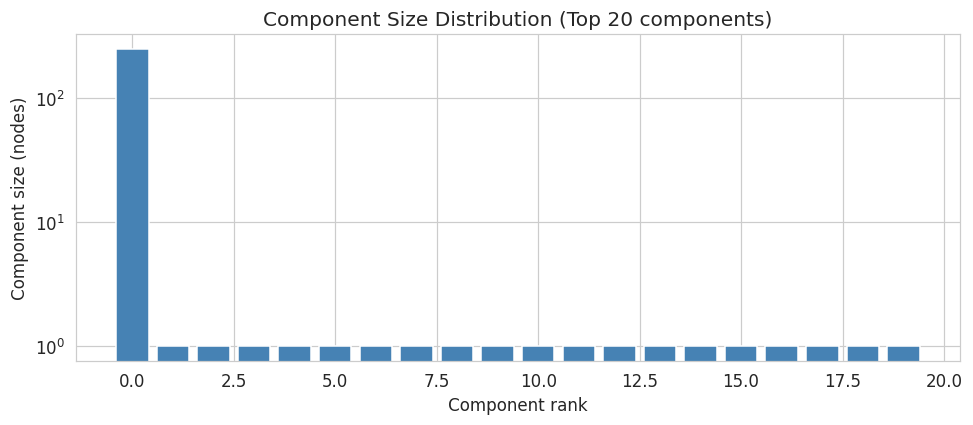

In [41]:
# Giant Connected Component analysis
components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes  = components[0]
G_gcc      = G.subgraph(gcc_nodes).copy()

print('=== Connected Components ===')
print(f'Total components:       {len(components)}')
print(f'GCC size (nodes):       {len(gcc_nodes):,} ({100*len(gcc_nodes)/G.number_of_nodes():.1f}% of all nodes)')
print(f'GCC edges:              {G_gcc.number_of_edges():,}')
print(f'2nd largest component:  {len(components[1]) if len(components) > 1 else 0} nodes')

# Component size distribution
comp_sizes = [len(c) for c in components]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(min(20, len(comp_sizes))), sorted(comp_sizes, reverse=True)[:20],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Component rank')
ax.set_ylabel('Component size (nodes)')
ax.set_title('Component Size Distribution (Top 20 components)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('d1_components.png', dpi=150, bbox_inches='tight')
plt.show()

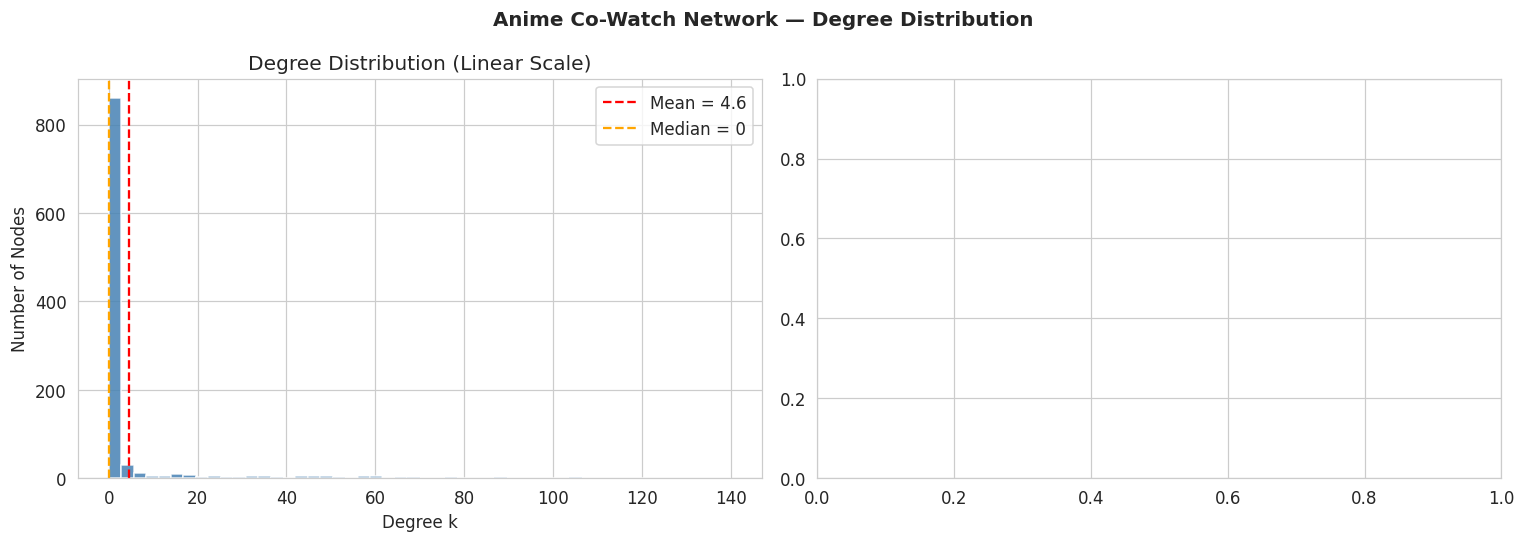

Degree statistics:
  Min:    0
  Max:    140
  Mean:   4.56
  Median: 0
  StdDev: 15.98
  Nodes with degree = max: 1
  Nodes with degree <= 10: 904 (90.4%)


In [95]:
# Degree distribution of the full network and GCC
degrees_all = [d for _, d in G.degree()]
degrees_gcc = [d for _, d in G_gcc.degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale — use bins instead of individual bars so they are visible
axes[0].hist(degrees_all, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Degree k')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].axvline(np.mean(degrees_all), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(degrees_all):.1f}')
axes[0].axvline(np.median(degrees_all), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median = {np.median(degrees_all):.0f}')
axes[0].legend()

plt.suptitle('Anime Co-Watch Network — Degree Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d1_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Degree statistics:')
print(f'  Min:    {min(degrees_all)}')
print(f'  Max:    {max(degrees_all)}')
print(f'  Mean:   {np.mean(degrees_all):.2f}')
print(f'  Median: {np.median(degrees_all):.0f}')
print(f'  StdDev: {np.std(degrees_all):.2f}')
print(f'  Nodes with degree = max: {sum(1 for d in degrees_all if d == max(degrees_all))}')
print(f'  Nodes with degree <= 10: {sum(1 for d in degrees_all if d <= 10)} ({100*sum(1 for d in degrees_all if d <= 10)/len(degrees_all):.1f}%)')

---
## Deliverable 3 — Community Detection & Genre Alignment

We apply **Louvain community detection** to the co-watch network (GCC) and measure how well the discovered behavioral communities align with the labeled genre taxonomy. We also build a **genre co-occurrence network** from metadata alone and compare its structure to the behavioral communities.

**Metrics used:**
- **NMI (Normalized Mutual Information):** measures how much knowing the community label tells you about the genre, and vice versa
- **Genre purity:** fraction of the majority genre within each community
- **Bridge anime:** nodes with many cross-community edges (high inter-community betweenness)

Running community detection on GCC...
Method: Greedy Modularity
Number of communities: 3
Modularity Q:          0.1295
Largest community:     100 nodes
Top 10 community sizes: [100, 79, 68]


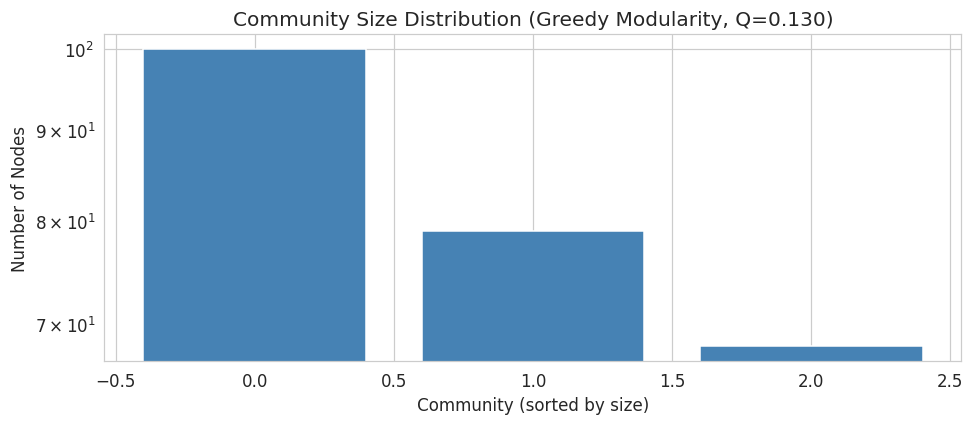

In [99]:
# Community detection on the GCC
print('Running community detection on GCC...')
if HAVE_LOUVAIN:
    try:
        partition = community_louvain.best_partition(G_gcc, random_state=RANDOM_SEED)
        communities = defaultdict(list)
        for node, comm_id in partition.items():
            communities[comm_id].append(node)
        method = 'Louvain'
    except Exception as e:
        print(f'Louvain failed ({e}), falling back to greedy modularity')
        HAVE_LOUVAIN = False

if not HAVE_LOUVAIN:
    from networkx.algorithms.community import greedy_modularity_communities
    comm_list = list(greedy_modularity_communities(G_gcc))
    partition  = {}
    communities = {}
    for i, comm in enumerate(comm_list):
        communities[i] = list(comm)
        for node in comm:
            partition[node] = i
    method = 'Greedy Modularity'

n_communities = len(communities)
comm_sizes = sorted([len(v) for v in communities.values()], reverse=True)
if HAVE_LOUVAIN:
    modularity = community_louvain.modularity(partition, G_gcc)
else:
    modularity = nx.community.modularity(G_gcc, [set(v) for v in communities.values()])

print(f'Method: {method}')
print(f'Number of communities: {n_communities}')
print(f'Modularity Q:          {modularity:.4f}')
print(f'Largest community:     {comm_sizes[0]} nodes')
print(f'Top 10 community sizes: {comm_sizes[:10]}')

# Plot community size distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(comm_sizes)), comm_sizes, color='steelblue', edgecolor='white')
ax.set_xlabel('Community (sorted by size)')
ax.set_ylabel('Number of Nodes')
ax.set_title(f'Community Size Distribution ({method}, Q={modularity:.3f})')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('d3_community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

Normalized Mutual Information (NMI): 0.0542
  (0 = random alignment, 1 = perfect alignment)

Overall genre purity: 0.4984

Top 10 most genre-pure communities (min 5 members):
Comm   Purity   Size    Dominant Genre
---------------------------------------------
2      0.544    68      Action
1      0.481    79      Action
0      0.470    100     Action


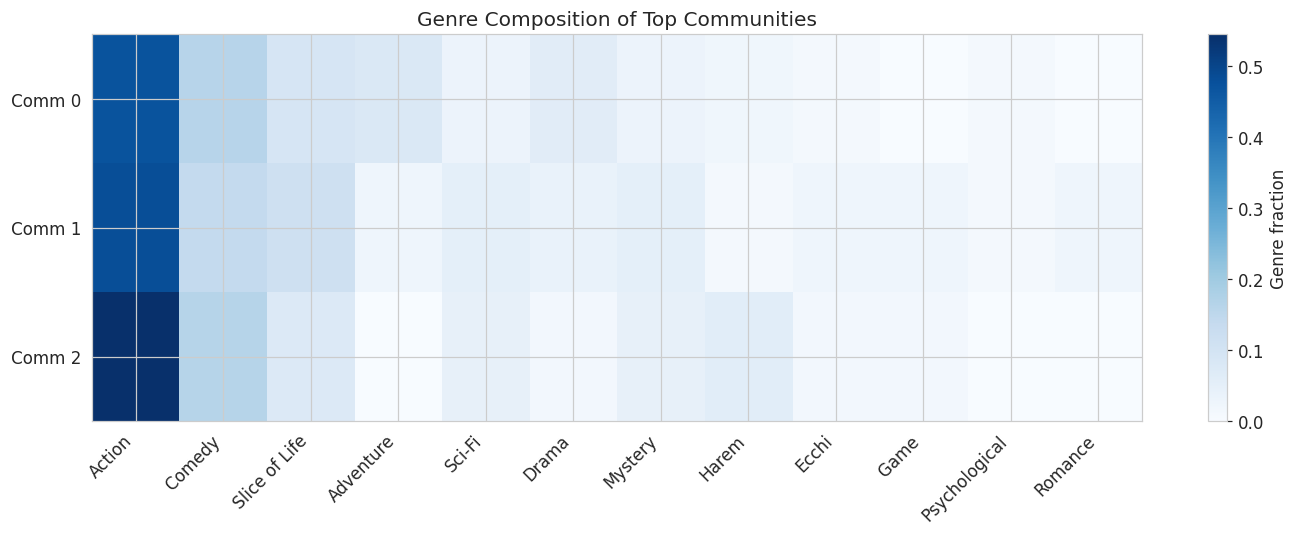

In [100]:
# Genre alignment: compare community labels with primary genre labels

# Get primary genre for each anime in GCC
node_genres = {}
node_comms  = {}
for node in G_gcc.nodes():
    genres_str = G_gcc.nodes[node].get('genres', '')
    if genres_str and genres_str != 'nan' and genres_str != '':
        primary = genres_str.split(',')[0].strip()
    else:
        primary = 'Unknown'
    node_genres[node] = primary
    node_comms[node]  = partition.get(node, -1)

# Filter nodes with known genres and valid community
valid_nodes = [n for n in G_gcc.nodes() if node_genres[n] != 'Unknown' and node_comms[n] >= 0]
genre_labels = [node_genres[n] for n in valid_nodes]
comm_labels  = [node_comms[n]  for n in valid_nodes]

# NMI
nmi = normalized_mutual_info_score(genre_labels, comm_labels)
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')
print(f'  (0 = random alignment, 1 = perfect alignment)')

# Genre purity per community (for top communities)
comm_genre_dist = defaultdict(Counter)
for node in valid_nodes:
    comm_genre_dist[node_comms[node]][node_genres[node]] += 1

purity_scores = []
for comm_id, genre_counts in comm_genre_dist.items():
    total = sum(genre_counts.values())
    majority = max(genre_counts.values())
    purity = majority / total
    purity_scores.append((comm_id, purity, total, genre_counts.most_common(1)[0][0]))

purity_scores.sort(key=lambda x: -x[1])

print(f'\nOverall genre purity: {np.mean([p for _, p, t, _ in purity_scores if t >= 5]):.4f}')
print(f'\nTop 10 most genre-pure communities (min 5 members):')
print(f'{"Comm":<6} {"Purity":<8} {"Size":<7} {"Dominant Genre"}')
print('-' * 45)
for cid, pur, sz, dom in [x for x in purity_scores if x[2] >= 5][:10]:
    print(f'{cid:<6} {pur:<8.3f} {sz:<7} {dom}')

# Heatmap: community vs genre (top communities and genres)
top_comm_ids  = [c for c, p, t, _ in sorted(purity_scores, key=lambda x: -x[2])[:8] if t >= 10]
all_genres    = list(set(genre_labels))
top_genres    = [g for g, _ in Counter(genre_labels).most_common(12)]

heat_mat = np.zeros((len(top_comm_ids), len(top_genres)))
for row_i, cid in enumerate(top_comm_ids):
    gc = comm_genre_dist[cid]
    total = sum(gc.values())
    for col_j, genre in enumerate(top_genres):
        heat_mat[row_i, col_j] = gc.get(genre, 0) / total

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(heat_mat, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Genre fraction')
ax.set_xticks(range(len(top_genres))); ax.set_xticklabels(top_genres, rotation=45, ha='right')
ax.set_yticks(range(len(top_comm_ids))); ax.set_yticklabels([f'Comm {c}' for c in top_comm_ids])
ax.set_title('Genre Composition of Top Communities')
plt.tight_layout()
plt.savefig('d3_community_genre_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Genre co-occurrence network: 25 nodes, 249 edges


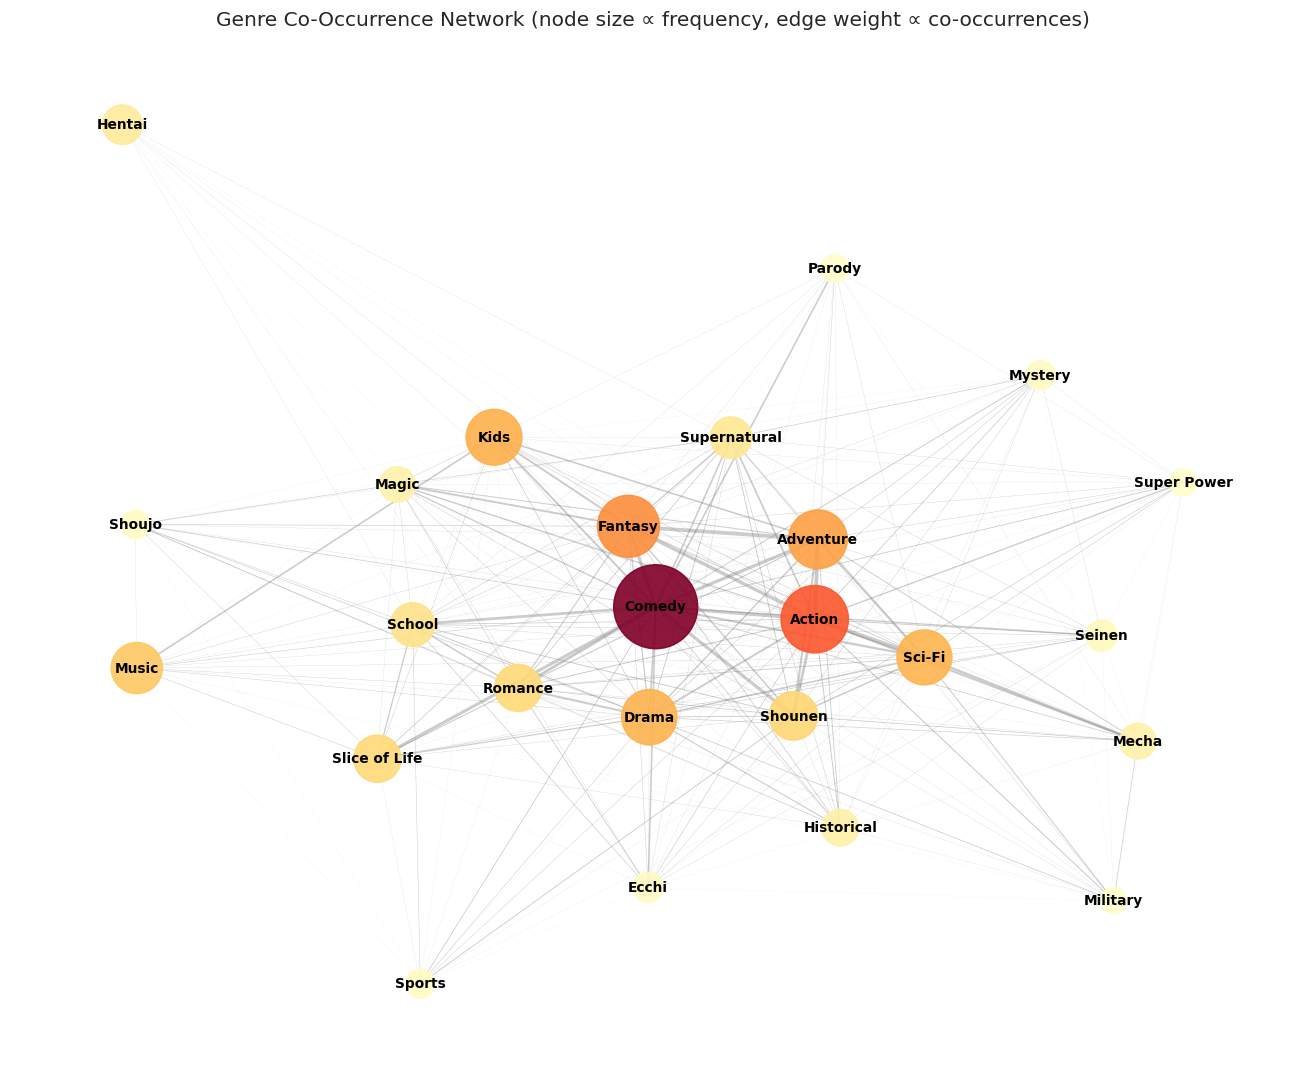

In [42]:
# Genre co-occurrence network from metadata
genre_pair_counts = Counter()
genre_counts_single = Counter()

for _, row in anime_df.dropna(subset=['Genres']).iterrows():
    genres = [g.strip() for g in str(row['Genres']).split(',') if g.strip() and g.strip() != 'nan']
    for g in genres:
        genre_counts_single[g] += 1
    for g1, g2 in combinations(sorted(set(genres)), 2):
        genre_pair_counts[(g1, g2)] += 1

# Build genre graph
G_genre = nx.Graph()
top_genres_meta = [g for g, c in genre_counts_single.most_common(25)]
G_genre.add_nodes_from(top_genres_meta)

MIN_GENRE_COOCCUR = 20
for (g1, g2), cnt in genre_pair_counts.items():
    if g1 in top_genres_meta and g2 in top_genres_meta and cnt >= MIN_GENRE_COOCCUR:
        G_genre.add_edge(g1, g2, weight=cnt)

print(f'Genre co-occurrence network: {G_genre.number_of_nodes()} nodes, {G_genre.number_of_edges()} edges')

# Visualize genre network
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_genre, seed=RANDOM_SEED, k=2.5)
node_sizes = [genre_counts_single.get(n, 1) * 0.5 for n in G_genre.nodes()]
edge_weights = [G_genre[u][v]['weight'] for u, v in G_genre.edges()]
max_w = max(edge_weights) if edge_weights else 1

nx.draw_networkx_edges(G_genre, pos, ax=ax, alpha=0.4,
                        width=[2.5 * w / max_w for w in edge_weights],
                        edge_color='gray')
nx.draw_networkx_nodes(G_genre, pos, ax=ax,
                        node_size=node_sizes,
                        node_color=[genre_counts_single.get(n,1) for n in G_genre.nodes()],
                        cmap='YlOrRd', alpha=0.9)
nx.draw_networkx_labels(G_genre, pos, ax=ax, font_size=9, font_weight='bold')
ax.set_title('Genre Co-Occurrence Network (node size ∝ frequency, edge weight ∝ co-occurrences)')
ax.axis('off')
plt.tight_layout()
plt.savefig('d3_genre_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()


Building Genre Co-occurrence Network (Improved)...
Genre network: 25 nodes, 102 edges

Top central genres:
Drama: 0.708
Comedy: 0.625
Action: 0.625
Shounen: 0.583
Romance: 0.583


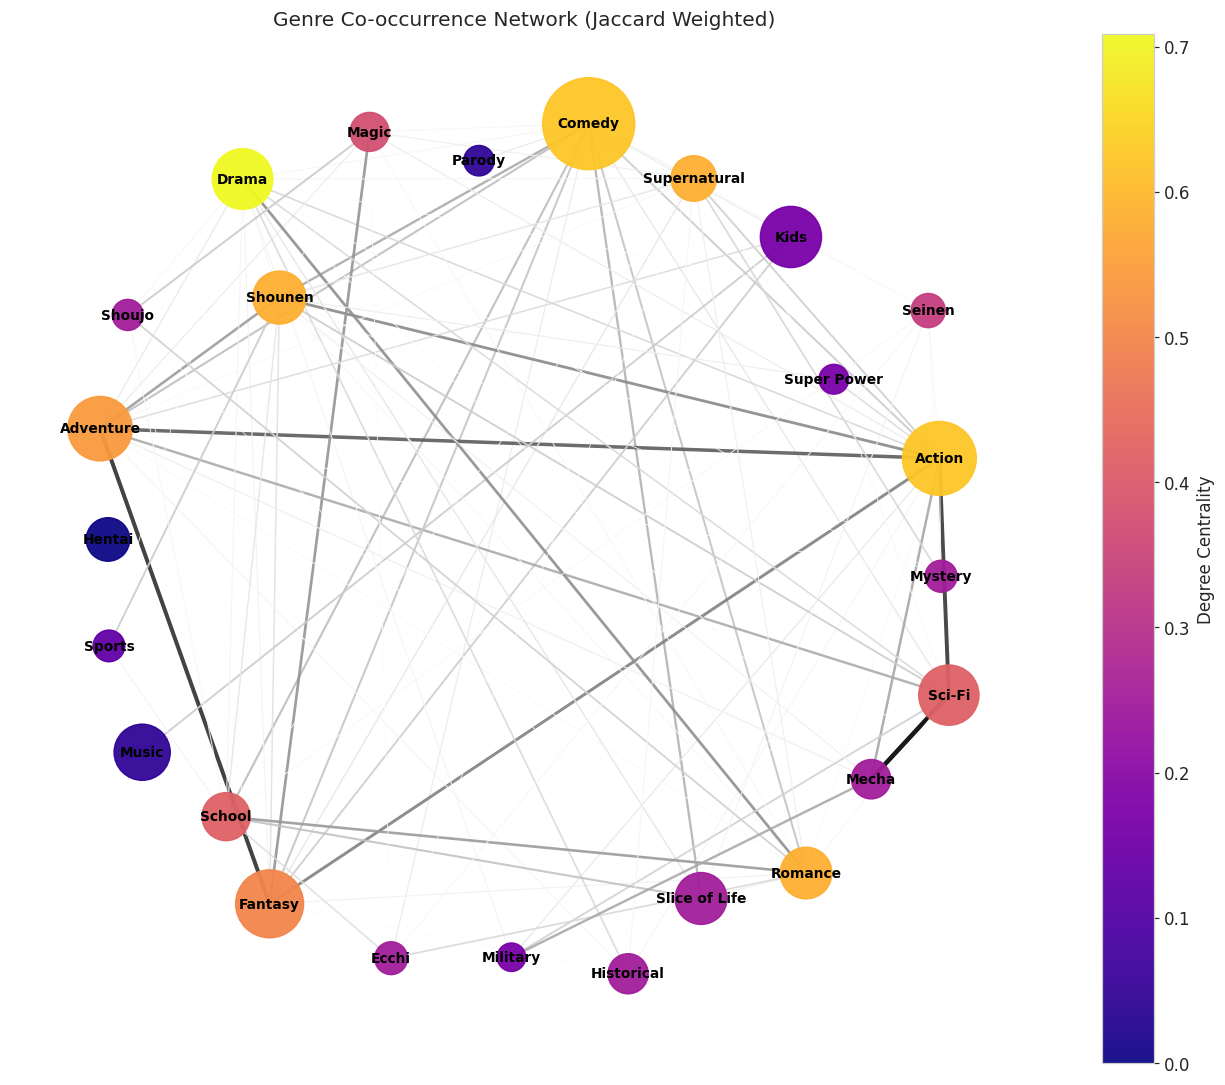


Detected 4 genre communities:
Community 0: ['Kids', 'Parody', 'Romance', 'Historical', 'Music', 'Ecchi', 'Comedy', 'Magic', 'Fantasy', 'Supernatural', 'Adventure']
Community 1: ['Slice of Life', 'School', 'Drama', 'Seinen', 'Shoujo', 'Sports', 'Mystery']
Community 2: ['Mecha', 'Action', 'Super Power', 'Sci-Fi', 'Military', 'Shounen']
Community 3: ['Hentai']


In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import combinations
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print('\nBuilding Genre Co-occurrence Network (Improved)...')

# -----------------------------
# COUNT GENRES
# -----------------------------
genre_pair_counts = Counter()
genre_counts_single = Counter()

for _, row in anime_df.dropna(subset=['Genres']).iterrows():
    genres = [
        g.strip() for g in str(row['Genres']).split(',')
        if g.strip() and g.strip().lower() != 'nan'
    ]

    unique_genres = set(genres)

    for g in unique_genres:
        genre_counts_single[g] += 1

    for g1, g2 in combinations(sorted(unique_genres), 2):
        genre_pair_counts[(g1, g2)] += 1

# -----------------------------
# SELECT TOP GENRES
# -----------------------------
top_genres_meta = [g for g, _ in genre_counts_single.most_common(25)]

# -----------------------------
# BUILD GRAPH (JACCARD WEIGHT)
# -----------------------------
G_genre = nx.Graph()
G_genre.add_nodes_from(top_genres_meta)

MIN_EDGE_WEIGHT = 0.05  # threshold

for (g1, g2), cnt in genre_pair_counts.items():
    if g1 in top_genres_meta and g2 in top_genres_meta:

        denom = genre_counts_single[g1] + genre_counts_single[g2] - cnt
        weight = cnt / denom if denom > 0 else 0

        if weight >= MIN_EDGE_WEIGHT:
            G_genre.add_edge(g1, g2, weight=weight, raw_count=cnt)

print(f'Genre network: {G_genre.number_of_nodes()} nodes, {G_genre.number_of_edges()} edges')

# -----------------------------
# CENTRALITY
# -----------------------------
degree_centrality = nx.degree_centrality(G_genre)
top_central = sorted(degree_centrality.items(), key=lambda x: -x[1])[:5]

print('\nTop central genres:')
for g, c in top_central:
    print(f'{g}: {c:.3f}')

# -----------------------------
# VISUALIZATION (IMPROVED)
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G_genre, seed=RANDOM_SEED, k=2.0)

# Node properties
node_sizes = [genre_counts_single.get(n, 1) * 0.6 for n in G_genre.nodes()]
node_colors = [degree_centrality.get(n, 0) for n in G_genre.nodes()]

# Edge properties
edge_weights = [G_genre[u][v]['weight'] for u, v in G_genre.edges()]
max_w = max(edge_weights) if edge_weights else 1

# Normalize weights for color mapping
norm = mcolors.Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
cmap = cm.Greys  # darker = stronger

edge_colors = [cmap(norm(w)) for w in edge_weights]

# Draw edges (dark = strong)
nx.draw_networkx_edges(
    G_genre, pos,
    width=[3 * w / max_w for w in edge_weights],
    edge_color=edge_colors,
    alpha=0.9
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G_genre, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap='plasma',
    alpha=0.95
)

# Labels
nx.draw_networkx_labels(
    G_genre, pos,
    font_size=9,
    font_weight='bold'
)

# Colorbar
plt.colorbar(nodes, ax=ax, label='Degree Centrality')

ax.set_title('Genre Co-occurrence Network (Jaccard Weighted)')
ax.axis('off')

plt.tight_layout()
plt.savefig('d3_genre_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------
# COMMUNITY DETECTION
# -----------------------------
from networkx.algorithms.community import greedy_modularity_communities

genre_comms = list(greedy_modularity_communities(G_genre))

print(f'\nDetected {len(genre_comms)} genre communities:')
for i, comm in enumerate(genre_comms):
    print(f'Community {i}: {list(comm)}')

In [43]:
# Bridge anime: nodes that connect different communities
# Measure: fraction of neighbors in OTHER communities (inter-community ratio)
bridge_scores = {}
for node in G_gcc.nodes():
    if node not in partition:
        continue
    home_comm = partition[node]
    neighbors = list(G_gcc.neighbors(node))
    if len(neighbors) == 0:
        continue
    other_comm_neighbors = sum(1 for nb in neighbors if partition.get(nb, -1) != home_comm)
    bridge_scores[node] = other_comm_neighbors / len(neighbors)

# Top bridges (with at least 5 neighbors)
top_bridges = sorted(
    [(n, s) for n, s in bridge_scores.items() if G_gcc.degree(n) >= 5],
    key=lambda x: -x[1]
)[:15]

print('Top 15 Bridge Anime (highest inter-community neighbor fraction):')
print(f'{"Rank":<5} {"Anime Name":<45} {"Bridge Score":<14} {"Degree":<8} {"Community"}')
print('-' * 85)
for rank, (node, score) in enumerate(top_bridges, 1):
    name = G_gcc.nodes[node].get('name', str(node))[:42]
    comm = partition.get(node, '?')
    deg  = G_gcc.degree(node)
    print(f'{rank:<5} {name:<45} {score:<14.3f} {deg:<8} {comm}')

Top 15 Bridge Anime (highest inter-community neighbor fraction):
Rank  Anime Name                                    Bridge Score   Degree   Community
-------------------------------------------------------------------------------------
1     Yuri!!! on Ice                                0.558          1999     1
2     91 Days                                       0.558          1999     1
3     Kobayashi-san Chi no Maid Dragon              0.558          1999     1
4     Ajin 2nd Season                               0.558          1999     1
5     Saiki Kusuo no Ψ-nan                          0.558          1999     1
6     Violet Evergarden                             0.558          1999     1
7     Boku no Hero Academia 2nd Season              0.558          1999     1
8     Masamune-kun no Revenge                       0.558          1999     1
9     Little Witch Academia (TV)                    0.558          1999     1
10    Ao no Exorcist: Kyoto Fujouou-hen             0.558    